Num contexts: 500
Num base pairs: 500
Num all pairs : 3000
Step    1 | KL DPO: 0.8491, KL DPO2: 0.8485 | R DPO: -0.1608, R DPO2: -0.1607 | cos(DPO): 0.868, cos(DPO2): 0.901
Step   10 | KL DPO: 0.6003, KL DPO2: 0.5982 | R DPO: 0.5759, R DPO2: 0.5862 | cos(DPO): 0.375, cos(DPO2): 0.476
Step   20 | KL DPO: 0.4744, KL DPO2: 0.4653 | R DPO: 1.0067, R DPO2: 1.0513 | cos(DPO): 0.135, cos(DPO2): 0.328
Step   30 | KL DPO: 0.4015, KL DPO2: 0.3905 | R DPO: 1.2900, R DPO2: 1.3215 | cos(DPO): 0.409, cos(DPO2): 0.177
Step   40 | KL DPO: 0.3336, KL DPO2: 0.3401 | R DPO: 1.5350, R DPO2: 1.5091 | cos(DPO): 0.449, cos(DPO2): 0.319
Step   50 | KL DPO: 0.3015, KL DPO2: 0.2981 | R DPO: 1.6963, R DPO2: 1.6648 | cos(DPO): 0.196, cos(DPO2): 0.236
Step   60 | KL DPO: 0.2707, KL DPO2: 0.2663 | R DPO: 1.8301, R DPO2: 1.7771 | cos(DPO): 0.124, cos(DPO2): 0.192
Step   70 | KL DPO: 0.2429, KL DPO2: 0.2373 | R DPO: 1.9185, R DPO2: 1.8799 | cos(DPO): 0.079, cos(DPO2): 0.022
Step   80 | KL DPO: 0.2296, KL DPO2: 0.2174

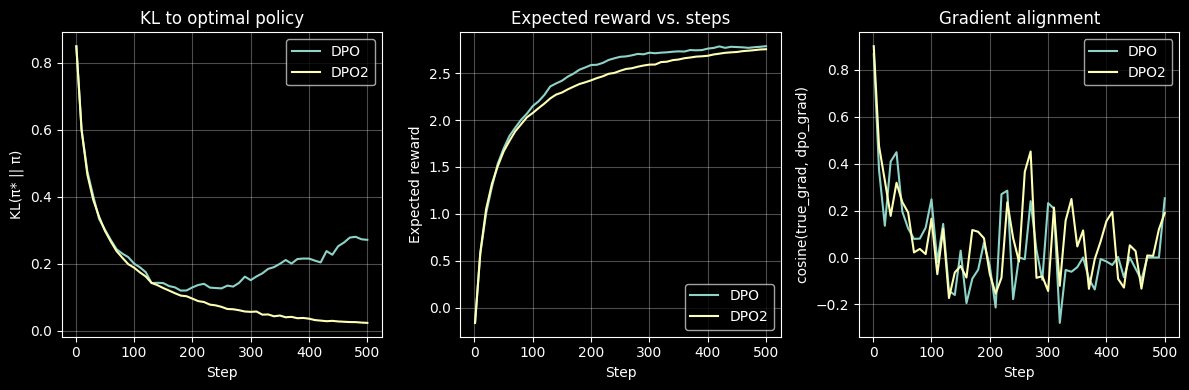

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import math
import matplotlib.pyplot as plt

# =========================
# Config / Hyperparameters
# =========================

seed = 42
torch.manual_seed(seed)
random.seed(seed)

device = torch.device("cpu")

num_contexts = 500  # number of distinct x's
context_dim = 10
num_actions = 4

beta_reward = 1.0  # temperature for optimal policy π*
beta_dpo = 5.0  # temperature/scaling inside DPO loss

num_steps = 500
eval_interval = 10

batch_size_contexts = 32
target_grad_norm = 1.0  # normalize gradients to this norm

lr = 0.1

# =========================
# Synthetic Environment
# =========================

# True reward parameter: r*(x, a) = w_true[a] · x
w_true = torch.randn(num_actions, context_dim, device=device)

# Sample contexts
contexts = torch.randn(num_contexts, context_dim, device=device)

# Compute true rewards for all (context, action)
# rewards[i, a] = r*(x_i, a)
rewards = torch.einsum("ad,nd->na", w_true, contexts)  # [N, A]

# =========================
# Preference Pair Construction
# =========================

# For each context, build all preference pairs (a+, a-) where r+ > r-
all_pairs = []  # list of (context_idx, a_pos, a_neg)
base_pairs = []  # one "strong" pair per context (best vs worst)

for i in range(num_contexts):
    r_i = rewards[i]
    # Sort actions by reward
    sorted_actions = torch.argsort(r_i, descending=True).tolist()
    # Best and worst
    best = sorted_actions[0]
    worst = sorted_actions[-1]
    if r_i[best] > r_i[worst]:
        base_pairs.append((i, best, worst))
    # All strictly better-vs-worse pairs
    for idx_pos in range(num_actions):
        for idx_neg in range(num_actions):
            a_pos = sorted_actions[idx_pos]
            a_neg = sorted_actions[idx_neg]
            if r_i[a_pos] > r_i[a_neg]:
                all_pairs.append((i, a_pos, a_neg))

print(f"Num contexts: {num_contexts}")
print(f"Num base pairs: {len(base_pairs)}")
print(f"Num all pairs : {len(all_pairs)}")


# =========================
# Models: reference and trainable policies
# =========================


class LinearPolicy(nn.Module):
    def __init__(self, num_actions, context_dim):
        super().__init__()
        # logits[a] = theta[a] · x
        self.theta = nn.Parameter(torch.randn(num_actions, context_dim) * 0.1)

    def logits(self, x):
        # x: [B, D] -> logits: [B, A]
        return x @ self.theta.t()

    def log_pi(self, x):
        return F.log_softmax(self.logits(x), dim=-1)

    def pi(self, x):
        return F.softmax(self.logits(x), dim=-1)


# Reference policy π_ref (fixed)
pi_ref = LinearPolicy(num_actions, context_dim).to(device)
for p in pi_ref.parameters():
    p.requires_grad_(False)

# Two trainable policies: DPO and DPO2 (start from same init as ref)
pi_dpo = LinearPolicy(num_actions, context_dim).to(device)
pi_dpo.theta.data.copy_(pi_ref.theta.data)
pi_dpo2 = LinearPolicy(num_actions, context_dim).to(device)
pi_dpo2.theta.data.copy_(pi_ref.theta.data)

opt_dpo = torch.optim.SGD(pi_dpo.parameters(), lr=lr)
opt_dpo2 = torch.optim.SGD(pi_dpo2.parameters(), lr=lr)


# =========================
# Helper Functions
# =========================


def compute_optimal_policy_probs(x_batch):
    # Given contexts x_batch [B, D], compute optimal policy π*(a|x)
    # as Boltzmann over true reward r*(x,a).
    # Returns: π_star [B, A] and rewards_batch [B, A]
    with torch.no_grad():
        # rewards_batch[b, a] = w_true[a] · x_b
        rewards_batch = torch.einsum("ad,bd->ba", w_true, x_batch)
        logits_star = beta_reward * rewards_batch
        pi_star = F.softmax(logits_star, dim=-1)
    return pi_star, rewards_batch


def dpo_loss_from_pairs(policy, ref_policy, pair_batch):
    # DPO loss on a batch of preference pairs.
    # pair_batch: list of (context_idx, a_pos, a_neg)
    if len(pair_batch) == 0:
        return torch.tensor(0.0, device=device)

    idxs = torch.tensor([p[0] for p in pair_batch], device=device, dtype=torch.long)
    a_pos = torch.tensor([p[1] for p in pair_batch], device=device, dtype=torch.long)
    a_neg = torch.tensor([p[2] for p in pair_batch], device=device, dtype=torch.long)

    x_batch = contexts[idxs]  # [B, D]

    log_pi = policy.log_pi(x_batch)  # [B, A]
    log_pi_ref = ref_policy.log_pi(x_batch)  # [B, A] (no grad)

    log_pi_pos = log_pi[torch.arange(len(pair_batch)), a_pos]
    log_pi_neg = log_pi[torch.arange(len(pair_batch)), a_neg]
    log_ref_pos = log_pi_ref[torch.arange(len(pair_batch)), a_pos]
    log_ref_neg = log_pi_ref[torch.arange(len(pair_batch)), a_neg]

    # Standard DPO objective:
    # L = - E[ log σ( β ( (logπ(y+)-logπ_ref(y+)) - (logπ(y-)-logπ_ref(y-)) ) ) ]
    diff_model = log_pi_pos - log_pi_neg
    diff_ref = log_ref_pos - log_ref_neg
    inside = beta_dpo * (diff_model - diff_ref)
    loss = -torch.log(torch.sigmoid(inside) + 1e-8).mean()
    return loss


def normalize_gradients(model, target_norm=1.0, eps=1e-8):
    # Rescale gradients on model parameters so that global L2 norm is target_norm.
    with torch.no_grad():
        grads = []
        for p in model.parameters():
            if p.grad is not None:
                grads.append(p.grad.view(-1))
        if not grads:
            return
        flat = torch.cat(grads)
        norm = flat.norm() + eps
        scale = target_norm / norm
        for p in model.parameters():
            if p.grad is not None:
                p.grad.mul_(scale)


def flatten_grad(model):
    grads = []
    for p in model.parameters():
        if p.grad is not None:
            grads.append(p.grad.view(-1))
    if not grads:
        return torch.zeros(1, device=device)
    return torch.cat(grads)


def compute_KL_and_reward(model, ctx_idx):
    # Compute KL(π* || π_model) and expected reward E[r] on a set of contexts.
    idxs = torch.tensor(ctx_idx, device=device, dtype=torch.long)
    x_batch = contexts[idxs]
    with torch.no_grad():
        pi_star, rewards_batch = compute_optimal_policy_probs(x_batch)
        pi_model = model.pi(x_batch)
        # KL(π* || π) = sum π* (log π* - log π)
        kl = (
            (pi_star * (torch.log(pi_star + 1e-8) - torch.log(pi_model + 1e-8)))
            .sum(dim=-1)
            .mean()
        )
        expected_r = (pi_model * rewards_batch).sum(dim=-1).mean()
    return kl.item(), expected_r.item()


def compute_true_policy_gradient(model, ctx_idx):
    # Compute gradient of negative expected reward (so gradient descent is reward-maximizing)
    # on a subset of contexts. Returns flattened gradient tensor.
    idxs = torch.tensor(ctx_idx, device=device, dtype=torch.long)
    x_batch = contexts[idxs]  # [B, D]
    rewards_batch = rewards[idxs]  # [B, A]

    # Forward
    pi_model = model.pi(x_batch)
    expected_r = (pi_model * rewards_batch).sum(dim=-1).mean()
    loss = -expected_r  # we want grad of negative expected reward

    # Backward
    model.zero_grad()
    loss.backward()
    g_true = flatten_grad(model).detach()
    return g_true


def compute_dpo_gradient(model, ref_policy, pair_subset):
    # Compute gradient of DPO loss on a subset of preference pairs.
    # Returns flattened gradient tensor and scalar loss.
    model.zero_grad()
    loss = dpo_loss_from_pairs(model, ref_policy, pair_subset)
    loss.backward()
    g_dpo = flatten_grad(model).detach()
    return g_dpo, loss.item()


def cosine_similarity(a, b, eps=1e-8):
    return torch.dot(a, b) / (a.norm() * b.norm() + eps)


# Choose a fixed evaluation subset of contexts
eval_ctx_idx = random.sample(range(num_contexts), k=min(100, num_contexts))

# =========================
# Training Loop
# =========================

history_steps = []
history_kl_dpo = []
history_kl_dpo2 = []
history_r_dpo = []
history_r_dpo2 = []
history_cos_dpo = []
history_cos_dpo2 = []

for step in range(1, num_steps + 1):
    # ---- DPO (baseline) ----
    opt_dpo.zero_grad()
    # sample a batch of contexts, then use their base_pairs
    batch_ctx_idx = random.sample(range(num_contexts), k=batch_size_contexts)
    batch_pairs_dpo = [base_pairs[i] for i in batch_ctx_idx]
    loss_dpo = dpo_loss_from_pairs(pi_dpo, pi_ref, batch_pairs_dpo)
    loss_dpo.backward()
    normalize_gradients(pi_dpo, target_grad_norm)
    opt_dpo.step()

    # ---- DPO2 (uses base_pairs + extra all_pairs for same contexts) ----
    opt_dpo2.zero_grad()
    batch_ctx_idx2 = batch_ctx_idx  # use same contexts for fairness
    batch_pairs_dpo2 = []

    # Add base pair for each context
    for i in batch_ctx_idx2:
        batch_pairs_dpo2.append(base_pairs[i])

    # Add all extra preference relations within those contexts
    # (this is the "interconnected relationships" part)
    for ctx, a_pos, a_neg in all_pairs:
        if ctx in batch_ctx_idx2:
            batch_pairs_dpo2.append((ctx, a_pos, a_neg))

    loss_dpo2 = dpo_loss_from_pairs(pi_dpo2, pi_ref, batch_pairs_dpo2)
    loss_dpo2.backward()
    normalize_gradients(pi_dpo2, target_grad_norm)
    opt_dpo2.step()

    # ---- Evaluation ----
    if step % eval_interval == 0 or step == 1:
        kl1, r1 = compute_KL_and_reward(pi_dpo, eval_ctx_idx)
        kl2, r2 = compute_KL_and_reward(pi_dpo2, eval_ctx_idx)

        # Gradient alignment with true reward gradient
        # Use a smaller subset for gradient computations to keep things cheap
        grad_ctx_idx = random.sample(eval_ctx_idx, k=min(32, len(eval_ctx_idx)))

        # For DPO model
        g_true_1 = compute_true_policy_gradient(pi_dpo, grad_ctx_idx)
        # build DPO pair subset for these contexts
        pair_subset_1 = [base_pairs[i] for i in grad_ctx_idx]
        g_dpo_1, _ = compute_dpo_gradient(pi_dpo, pi_ref, pair_subset_1)
        cos1 = cosine_similarity(g_true_1, g_dpo_1).item()

        # For DPO2 model
        g_true_2 = compute_true_policy_gradient(pi_dpo2, grad_ctx_idx)
        pair_subset_2 = []
        for i in grad_ctx_idx:
            pair_subset_2.append(base_pairs[i])
        for ctx, a_pos, a_neg in all_pairs:
            if ctx in grad_ctx_idx:
                pair_subset_2.append((ctx, a_pos, a_neg))
        g_dpo_2, _ = compute_dpo_gradient(pi_dpo2, pi_ref, pair_subset_2)
        cos2 = cosine_similarity(g_true_2, g_dpo_2).item()

        history_steps.append(step)
        history_kl_dpo.append(kl1)
        history_kl_dpo2.append(kl2)
        history_r_dpo.append(r1)
        history_r_dpo2.append(r2)
        history_cos_dpo.append(cos1)
        history_cos_dpo2.append(cos2)

        print(
            f"Step {step:4d} | "
            f"KL DPO: {kl1:.4f}, KL DPO2: {kl2:.4f} | "
            f"R DPO: {r1:.4f}, R DPO2: {r2:.4f} | "
            f"cos(DPO): {cos1:.3f}, cos(DPO2): {cos2:.3f}"
        )

# =========================
# Plot results
# =========================

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history_steps, history_kl_dpo, label="DPO")
plt.plot(history_steps, history_kl_dpo2, label="DPO2")
plt.xlabel("Step")
plt.ylabel("KL(π* || π)")
plt.title("KL to optimal policy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history_steps, history_r_dpo, label="DPO")
plt.plot(history_steps, history_r_dpo2, label="DPO2")
plt.xlabel("Step")
plt.ylabel("Expected reward")
plt.title("Expected reward vs. steps")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history_steps, history_cos_dpo, label="DPO")
plt.plot(history_steps, history_cos_dpo2, label="DPO2")
plt.xlabel("Step")
plt.ylabel("cosine(true_grad, dpo_grad)")
plt.title("Gradient alignment")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import math
import matplotlib.pyplot as plt

# =========================
# Config / Hyperparameters
# =========================

seed = 42
torch.manual_seed(seed)
random.seed(seed)

device = torch.device("cpu")

num_contexts = 500  # number of distinct x's
context_dim = 50
num_actions = 10

beta_reward = 1.0  # temperature for optimal policy π*
beta_dpo = 5.0  # temperature/scaling inside DPO loss

num_steps = 500
eval_interval = 10

batch_size_contexts = 32
target_grad_norm = 1.0  # normalize gradients to this norm

lr_policy = 0.1  # learning rate for policies

# Value model (for guessing the preference graph)
value_lr = 0.1
value_epochs = 1000
value_batch_size = 128

# =========================
# Synthetic Environment
# =========================

# True reward parameter: r*(x, a) = w_true[a] · x
w_true = torch.randn(num_actions, context_dim, device=device)

# Sample contexts
contexts = torch.randn(num_contexts, context_dim, device=device)

# Compute true rewards for all (context, action)
# rewards[i, a] = r*(x_i, a)
rewards = torch.einsum("ad,nd->na", w_true, contexts)  # [N, A]

# =========================
# Preference Pair Construction (observed data)
# =========================
# We only assume access to ONE strong pair per context: best vs worst.

base_pairs = []  # one "strong" pair per context (best vs worst)

for i in range(num_contexts):
    r_i = rewards[i]
    sorted_actions = torch.argsort(r_i, descending=True).tolist()
    best = sorted_actions[0]
    worst = sorted_actions[-1]
    if r_i[best] > r_i[worst]:
        base_pairs.append((i, best, worst))
    else:
        # extremely unlikely with continuous rewards, but just in case
        # fall back to a random action pair with strictly better reward
        for a_pos in sorted_actions:
            for a_neg in reversed(sorted_actions):
                if r_i[a_pos] > r_i[a_neg]:
                    base_pairs.append((i, a_pos, a_neg))
                    break
            if len(base_pairs) == i + 1:
                break

assert len(base_pairs) == num_contexts, "We expect one base pair per context."

print(f"Num contexts: {num_contexts}")
print(f"Num base pairs (observed): {len(base_pairs)}")

# =========================
# Value Model for Guessing Preference Graph
# =========================
# Each (context, action) "option" gets a scalar value v[i, a].
# We fit v to the observed base_pairs by maximizing:
#   sum log σ(v_pos - v_neg)
# Then we use these fitted values to infer a full preference graph.

# v_options[i, a] is the value for action a in context i
v_options = nn.Parameter(0.01 * torch.randn(num_contexts, num_actions, device=device))

opt_value = torch.optim.SGD([v_options], lr=value_lr)


def value_model_loss(pair_batch):
    # pair_batch: list of (context_idx, a_pos, a_neg)
    if len(pair_batch) == 0:
        return torch.tensor(0.0, device=device)

    idxs = torch.tensor([p[0] for p in pair_batch], device=device, dtype=torch.long)
    a_pos = torch.tensor([p[1] for p in pair_batch], device=device, dtype=torch.long)
    a_neg = torch.tensor([p[2] for p in pair_batch], device=device, dtype=torch.long)

    v_pos = v_options[idxs, a_pos]
    v_neg = v_options[idxs, a_neg]

    diff = v_pos - v_neg
    # We maximize log σ(diff), so minimize -log σ(diff)
    loss = -torch.log(torch.sigmoid(diff) + 1e-8).mean()
    return loss


print("\n=== Training value model to infer preference graph from base pairs ===")
for epoch in range(1, value_epochs + 1):
    batch = random.sample(base_pairs, k=min(value_batch_size, len(base_pairs)))
    opt_value.zero_grad()
    loss_v = value_model_loss(batch)
    loss_v.backward()
    opt_value.step()

    if epoch % (value_epochs // 10) == 0 or epoch == 1:
        print(f"Value epoch {epoch:4d}/{value_epochs} | loss: {loss_v.item():.4f}")

# =========================
# Build Guessed Preference Graph from v_options
# =========================

guessed_pairs_by_ctx = [[] for _ in range(num_contexts)]

with torch.no_grad():
    for i in range(num_contexts):
        v_i = v_options[i]  # [A]
        for a_pos in range(num_actions):
            for a_neg in range(num_actions):
                if a_pos == a_neg:
                    continue
                if v_i[a_pos] > v_i[a_neg]:
                    guessed_pairs_by_ctx[i].append((i, a_pos, a_neg))

# Some stats
num_guessed_total = sum(len(lst) for lst in guessed_pairs_by_ctx)
print(f"\nTotal guessed preference pairs (from value model): {num_guessed_total}")
print(f"Average guessed pairs per context: {num_guessed_total / num_contexts:.2f}")

# =========================
# Models: reference and trainable policies
# =========================


class LinearPolicy(nn.Module):
    def __init__(self, num_actions, context_dim):
        super().__init__()
        # logits[a] = theta[a] · x
        self.theta = nn.Parameter(torch.randn(num_actions, context_dim) * 0.1)

    def logits(self, x):
        # x: [B, D] -> logits: [B, A]
        return x @ self.theta.t()

    def log_pi(self, x):
        return F.log_softmax(self.logits(x), dim=-1)

    def pi(self, x):
        return F.softmax(self.logits(x), dim=-1)


# Reference policy π_ref (fixed)
pi_ref = LinearPolicy(num_actions, context_dim).to(device)
for p in pi_ref.parameters():
    p.requires_grad_(False)

# Two trainable policies: DPO and DPO2 (start from same init as ref)
pi_dpo = LinearPolicy(num_actions, context_dim).to(device)
pi_dpo.theta.data.copy_(pi_ref.theta.data)
pi_dpo2 = LinearPolicy(num_actions, context_dim).to(device)
pi_dpo2.theta.data.copy_(pi_ref.theta.data)

opt_dpo = torch.optim.SGD(pi_dpo.parameters(), lr=lr_policy)
opt_dpo2 = torch.optim.SGD(pi_dpo2.parameters(), lr=lr_policy)


# =========================
# Helper Functions
# =========================


def compute_optimal_policy_probs(x_batch):
    # Given contexts x_batch [B, D], compute optimal policy π*(a|x)
    # as Boltzmann over true reward r*(x,a).
    # Returns: π_star [B, A] and rewards_batch [B, A]
    with torch.no_grad():
        # rewards_batch[b, a] = w_true[a] · x_b
        rewards_batch = torch.einsum("ad,bd->ba", w_true, x_batch)
        logits_star = beta_reward * rewards_batch
        pi_star = F.softmax(logits_star, dim=-1)
    return pi_star, rewards_batch


def dpo_loss_from_pairs(policy, ref_policy, pair_batch):
    # DPO loss on a batch of preference pairs.
    # pair_batch: list of (context_idx, a_pos, a_neg)
    if len(pair_batch) == 0:
        return torch.tensor(0.0, device=device)

    idxs = torch.tensor([p[0] for p in pair_batch], device=device, dtype=torch.long)
    a_pos = torch.tensor([p[1] for p in pair_batch], device=device, dtype=torch.long)
    a_neg = torch.tensor([p[2] for p in pair_batch], device=device, dtype=torch.long)

    x_batch = contexts[idxs]  # [B, D]

    log_pi = policy.log_pi(x_batch)  # [B, A]
    log_pi_ref = ref_policy.log_pi(x_batch)  # [B, A] (no grad)

    log_pi_pos = log_pi[torch.arange(len(pair_batch)), a_pos]
    log_pi_neg = log_pi[torch.arange(len(pair_batch)), a_neg]
    log_ref_pos = log_pi_ref[torch.arange(len(pair_batch)), a_pos]
    log_ref_neg = log_pi_ref[torch.arange(len(pair_batch)), a_neg]

    # Standard DPO objective:
    # L = - E[ log σ( β ( (logπ(y+)-logπ_ref(y+)) - (logπ(y-)-logπ_ref(y-)) ) ) ]
    diff_model = log_pi_pos - log_pi_neg
    diff_ref = log_ref_pos - log_ref_neg
    inside = beta_dpo * (diff_model - diff_ref)
    loss = -torch.log(torch.sigmoid(inside) + 1e-8).mean()
    return loss


def normalize_gradients(model, target_norm=1.0, eps=1e-8):
    # Rescale gradients on model parameters so that global L2 norm is target_norm.
    with torch.no_grad():
        grads = []
        for p in model.parameters():
            if p.grad is not None:
                grads.append(p.grad.view(-1))
        if not grads:
            return
        flat = torch.cat(grads)
        norm = flat.norm() + eps
        scale = target_norm / norm
        for p in model.parameters():
            if p.grad is not None:
                p.grad.mul_(scale)


def flatten_grad(model):
    grads = []
    for p in model.parameters():
        if p.grad is not None:
            grads.append(p.grad.view(-1))
    if not grads:
        return torch.zeros(1, device=device)
    return torch.cat(grads)


def compute_KL_and_reward(model, ctx_idx):
    # Compute KL(π* || π_model) and expected reward E[r] on a set of contexts.
    idxs = torch.tensor(ctx_idx, device=device, dtype=torch.long)
    x_batch = contexts[idxs]
    with torch.no_grad():
        pi_star, rewards_batch = compute_optimal_policy_probs(x_batch)
        pi_model = model.pi(x_batch)
        # KL(π* || π) = sum π* (log π* - log π)
        kl = (
            (pi_star * (torch.log(pi_star + 1e-8) - torch.log(pi_model + 1e-8)))
            .sum(dim=-1)
            .mean()
        )
        expected_r = (pi_model * rewards_batch).sum(dim=-1).mean()
    return kl.item(), expected_r.item()


def compute_true_policy_gradient(model, ctx_idx):
    # Compute gradient of negative expected reward (so gradient descent is reward-maximizing)
    # on a subset of contexts. Returns flattened gradient tensor.
    idxs = torch.tensor(ctx_idx, device=device, dtype=torch.long)
    x_batch = contexts[idxs]  # [B, D]
    rewards_batch = rewards[idxs]  # [B, A]

    # Forward
    pi_model = model.pi(x_batch)
    expected_r = (pi_model * rewards_batch).sum(dim=-1).mean()
    loss = -expected_r  # we want grad of negative expected reward

    # Backward
    model.zero_grad()
    loss.backward()
    g_true = flatten_grad(model).detach()
    return g_true


def compute_dpo_gradient(model, ref_policy, pair_subset):
    # Compute gradient of DPO loss on a subset of preference pairs.
    # Returns flattened gradient tensor and scalar loss.
    model.zero_grad()
    loss = dpo_loss_from_pairs(model, ref_policy, pair_subset)
    loss.backward()
    g_dpo = flatten_grad(model).detach()
    return g_dpo, loss.item()


def cosine_similarity(a, b, eps=1e-8):
    return torch.dot(a, b) / (a.norm() * b.norm() + eps)


# Choose a fixed evaluation subset of contexts
eval_ctx_idx = random.sample(range(num_contexts), k=min(100, num_contexts))

# =========================
# Training Loop
# =========================

history_steps = []
history_kl_dpo = []
history_kl_dpo2 = []
history_r_dpo = []
history_r_dpo2 = []
history_cos_dpo = []
history_cos_dpo2 = []

print("\n=== Training DPO (base_pairs) vs DPO2 (base_pairs + guessed graph) ===")
for step in range(1, num_steps + 1):
    # ---- DPO (baseline) ----
    opt_dpo.zero_grad()
    # sample a batch of contexts, then use their base_pairs
    batch_ctx_idx = random.sample(range(num_contexts), k=batch_size_contexts)
    batch_pairs_dpo = [base_pairs[i] for i in batch_ctx_idx]
    loss_dpo = dpo_loss_from_pairs(pi_dpo, pi_ref, batch_pairs_dpo)
    loss_dpo.backward()
    normalize_gradients(pi_dpo, target_grad_norm)
    opt_dpo.step()

    # ---- DPO2 (uses base_pairs + guessed preference pairs for same contexts) ----
    opt_dpo2.zero_grad()
    batch_ctx_idx2 = batch_ctx_idx  # use same contexts for fairness
    batch_pairs_dpo2 = []
    loss_dpo2 = 0

    # Add base pair for each context (observed)
    for i in batch_ctx_idx2:
        batch_pairs_dpo2.append(base_pairs[i])
    loss_dpo2 += dpo_loss_from_pairs(pi_dpo2, pi_ref, batch_pairs_dpo2)
    loss_dpo2 += dpo_loss_from_pairs(pi_dpo2, pi_ref, batch_pairs_dpo2)
    loss_dpo2 += dpo_loss_from_pairs(pi_dpo2, pi_ref, batch_pairs_dpo2)

    # Add all guessed preference relations within those contexts
    # (this is our guessed "interconnected relationships" part)
    for ctx in batch_ctx_idx2:
        batch_pairs_dpo2.extend(guessed_pairs_by_ctx[ctx])

    loss_dpo2 += dpo_loss_from_pairs(pi_dpo2, pi_ref, batch_pairs_dpo2)
    loss_dpo2.backward()
    normalize_gradients(pi_dpo2, target_grad_norm)
    opt_dpo2.step()

    # ---- Evaluation ----
    if step % eval_interval == 0 or step == 1:
        kl1, r1 = compute_KL_and_reward(pi_dpo, eval_ctx_idx)
        kl2, r2 = compute_KL_and_reward(pi_dpo2, eval_ctx_idx)

        # Gradient alignment with true reward gradient
        grad_ctx_idx = random.sample(eval_ctx_idx, k=min(32, len(eval_ctx_idx)))

        # For DPO model: gradient based on its training loss (base_pairs only)
        g_true_1 = compute_true_policy_gradient(pi_dpo, grad_ctx_idx)
        pair_subset_1 = [base_pairs[i] for i in grad_ctx_idx]
        g_dpo_1, _ = compute_dpo_gradient(pi_dpo, pi_ref, pair_subset_1)
        cos1 = cosine_similarity(g_true_1, g_dpo_1).item()

        # For DPO2 model: gradient based on its training loss (base_pairs + guessed graph)
        g_true_2 = compute_true_policy_gradient(pi_dpo2, grad_ctx_idx)
        pair_subset_2 = []
        for i in grad_ctx_idx:
            pair_subset_2.append(base_pairs[i])
            pair_subset_2.extend(guessed_pairs_by_ctx[i])
        g_dpo_2, _ = compute_dpo_gradient(pi_dpo2, pi_ref, pair_subset_2)
        cos2 = cosine_similarity(g_true_2, g_dpo_2).item()

        history_steps.append(step)
        history_kl_dpo.append(kl1)
        history_kl_dpo2.append(kl2)
        history_r_dpo.append(r1)
        history_r_dpo2.append(r2)
        history_cos_dpo.append(cos1)
        history_cos_dpo2.append(cos2)

        print(
            f"Step {step:4d} | "
            f"KL DPO: {kl1:.4f}, KL DPO2: {kl2:.4f} | "
            f"R DPO: {r1:.4f}, R DPO2: {r2:.4f} | "
            f"cos(DPO): {cos1:.3f}, cos(DPO2): {cos2:.3f}"
        )

# =========================
# Plot results
# =========================

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history_steps, history_kl_dpo, label="DPO")
plt.plot(history_steps, history_kl_dpo2, label="DPO2 (guessed graph)")
plt.xlabel("Step")
plt.ylabel("KL(π* || π)")
plt.title("KL to optimal policy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history_steps, history_r_dpo, label="DPO")
plt.plot(history_steps, history_r_dpo2, label="DPO2 (guessed graph)")
plt.xlabel("Step")
plt.ylabel("Expected reward")
plt.title("Expected reward vs. steps")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history_steps, history_cos_dpo, label="DPO")
plt.plot(history_steps, history_cos_dpo2, label="DPO2 (guessed graph)")
plt.xlabel("Step")
plt.ylabel("cosine(true_grad, dpo_grad)")
plt.title("Gradient alignment")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# What I want:
# Have a random gpt-2 sized model pi ref. Have a noised version pi star.